In [19]:
from pyspark.sql import SparkSession

# Create or get existing Spark session
spark = SparkSession.builder.appName("DiabetesClassification").getOrCreate()


In [20]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [21]:
# Read the CSV file
df = spark.read.csv("diabetes.csv", header=True, inferSchema=True)
df.printSchema()
df.show(5)


root
 |-- Glucose: integer (nullable = true)
 |-- BMI: double (nullable = true)
 |-- Outcome: integer (nullable = true)

+-------+-----+-------+
|Glucose|  BMI|Outcome|
+-------+-----+-------+
|    141|33.02|      0|
|     83| 30.2|      0|
|    128|27.16|      0|
|    112|35.16|      1|
|     71|27.22|      0|
+-------+-----+-------+
only showing top 5 rows



In [22]:
# Show class balance
df.groupBy("Outcome").count().show()

# Check for null values
from pyspark.sql.functions import col
df.select([col(c).isNull().alias(c) for c in df.columns]).show()


+-------+-----+
|Outcome|count|
+-------+-----+
|      1|  174|
|      0|  326|
+-------+-----+

+-------+-----+-------+
|Glucose|  BMI|Outcome|
+-------+-----+-------+
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
|  false|false|  false|
+-------+-----+-------+
only showing top 20 rows



In [23]:
from pyspark.ml.feature import VectorAssembler

# Exclude the label column
feature_cols = [col for col in df.columns if col != 'Outcome']

# Assemble all features into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

assembled_df = assembler.transform(df).select("features", "Outcome")
assembled_df.show(5, truncate=False)


+-------------+-------+
|features     |Outcome|
+-------------+-------+
|[141.0,33.02]|0      |
|[83.0,30.2]  |0      |
|[128.0,27.16]|0      |
|[112.0,35.16]|1      |
|[71.0,27.22] |0      |
+-------------+-------+
only showing top 5 rows



In [24]:
train_data, test_data = assembled_df.randomSplit([0.8, 0.2], seed=42)
print(f"Training Rows: {train_data.count()}, Testing Rows: {test_data.count()}")


Training Rows: 426, Testing Rows: 74


In [25]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="Outcome")
lr_model = lr.fit(train_data)


In [26]:
predictions = lr_model.transform(test_data)
predictions.select("prediction", "probability", "Outcome").show(10)


+----------+--------------------+-------+
|prediction|         probability|Outcome|
+----------+--------------------+-------+
|       0.0|[0.98600251369337...|      0|
|       0.0|[0.95934632781470...|      0|
|       0.0|[0.93128542814537...|      0|
|       0.0|[0.95633792486677...|      0|
|       0.0|[0.94493397657734...|      0|
|       0.0|[0.87144845133038...|      0|
|       0.0|[0.91839679696055...|      0|
|       0.0|[0.81305647428735...|      0|
|       0.0|[0.82005917901456...|      0|
|       0.0|[0.98036185614856...|      0|
+----------+--------------------+-------+
only showing top 10 rows



In [27]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="Outcome")
auc = evaluator.evaluate(predictions)
print(f"AUC = {auc:.4f}")


AUC = 0.8550


In [10]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol="features", labelCol="Outcome")
dt_model = dt.fit(train_data)

dt_predictions = dt_model.transform(test_data)
dt_auc = evaluator.evaluate(dt_predictions)
print(f"Decision Tree AUC = {dt_auc:.4f}")


Decision Tree AUC = 0.5863


In [11]:
lr_model = lr.fit(train_data)
predictions = lr_model.transform(test_data)


In [12]:
predictions.select("features", "probability", "prediction", "Outcome").show(10, truncate=False)


+------------+-----------------------------------------+----------+-------+
|features    |probability                              |prediction|Outcome|
+------------+-----------------------------------------+----------+-------+
|[0.0,32.3]  |[0.9860025136933738,0.013997486306626228]|0.0       |0      |
|[56.0,24.22]|[0.9593463278147043,0.0406536721852957]  |0.0       |0      |
|[57.0,32.34]|[0.9312854281453778,0.06871457185462215] |0.0       |0      |
|[68.0,20.02]|[0.9563379248667706,0.043662075133229394]|0.0       |0      |
|[73.0,21.56]|[0.9449339765773449,0.0550660234226551]  |0.0       |0      |
|[74.0,35.46]|[0.8714484513303874,0.1285515486696126]  |0.0       |0      |
|[79.0,25.4] |[0.9183967969605576,0.08160320303944235] |0.0       |0      |
|[80.0,39.64]|[0.8130564742873589,0.18694352571264106] |0.0       |0      |
|[83.0,37.58]|[0.8200591790145612,0.17994082098543884] |0.0       |0      |
|[84.0,0.16] |[0.9803618561485657,0.019638143851434253]|0.0       |0      |
+-----------

In [28]:
# Filter correct positive predictions (True Positives)
predictions.filter((predictions.prediction == 1.0) & (predictions.Outcome == 1)) \
           .select("features", "probability", "prediction", "Outcome") \
           .show(truncate=False)


+-------------+----------------------------------------+----------+-------+
|features     |probability                             |prediction|Outcome|
+-------------+----------------------------------------+----------+-------+
|[140.0,42.84]|[0.38476519243098456,0.6152348075690155]|1.0       |1      |
|[152.0,33.66]|[0.4448509763104434,0.5551490236895567] |1.0       |1      |
|[155.0,34.46]|[0.4109840006928872,0.5890159993071128] |1.0       |1      |
|[158.0,42.36]|[0.2772879024204904,0.7227120975795096] |1.0       |1      |
|[162.0,48.66]|[0.18523172025247212,0.8147682797475279]|1.0       |1      |
|[167.0,37.66]|[0.2862828731152802,0.7137171268847198] |1.0       |1      |
|[170.0,35.0] |[0.30408762484877466,0.6959123751512253]|1.0       |1      |
|[177.0,35.56]|[0.2561165285167801,0.7438834714832199] |1.0       |1      |
|[181.0,30.0] |[0.3053864840741487,0.6946135159258513] |1.0       |1      |
|[181.0,40.38]|[0.18335530532296354,0.8166446946770365]|1.0       |1      |
|[183.0,28.6

In [29]:
# Show all rows where prediction and actual label differ
predictions.filter(predictions.prediction != predictions.Outcome) \
           .select("features", "probability", "prediction", "Outcome") \
           .show(truncate=False)



+-------------+----------------------------------------+----------+-------+
|features     |probability                             |prediction|Outcome|
+-------------+----------------------------------------+----------+-------+
|[84.0,29.26] |[0.8835529982856773,0.11644700171432265]|0.0       |1      |
|[95.0,34.4]  |[0.7983771439039046,0.20162285609609543]|0.0       |1      |
|[100.0,33.02]|[0.7893768975367834,0.21062310246321658]|0.0       |1      |
|[112.0,37.3] |[0.6676659179614892,0.3323340820385108] |0.0       |1      |
|[118.0,42.22]|[0.5512956153050589,0.4487043846949411] |0.0       |1      |
|[119.0,27.16]|[0.7598798278251148,0.24012017217488524]|0.0       |1      |
|[119.0,45.86]|[0.48535006288053495,0.514649937119465] |1.0       |0      |
|[120.0,29.2] |[0.7293014487447261,0.27069855125527387]|0.0       |1      |
|[124.0,28.26]|[0.7183834502062768,0.2816165497937232] |0.0       |1      |
|[124.0,33.1] |[0.650926825894653,0.349073174105347]   |0.0       |1      |
|[147.0,34.5

In [30]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="Outcome", predictionCol="prediction", metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print(f"Accuracy = {accuracy:.4f}")
print(f"Correct Prediction Percentage = {accuracy * 100:.2f}%")


Accuracy = 0.8378
Correct Prediction Percentage = 83.78%


In [31]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Precision (weighted)
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Outcome", predictionCol="prediction", metricName="weightedPrecision")
precision = precision_evaluator.evaluate(predictions)

# Recall (weighted)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Outcome", predictionCol="prediction", metricName="weightedRecall")
recall = recall_evaluator.evaluate(predictions)

# F1 Score (weighted)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="Outcome", predictionCol="prediction", metricName="f1")
f1 = f1_evaluator.evaluate(predictions)

print(f"Precision = {precision:.4f}")
print(f"Recall = {recall:.4f}")
print(f"F1 Score = {f1:.4f}")


Precision = 0.8374
Recall = 0.8378
F1 Score = 0.8308


In [33]:
# Convert to Pandas for plotting
preds_df = predictions.select("prediction", "Outcome").toPandas()


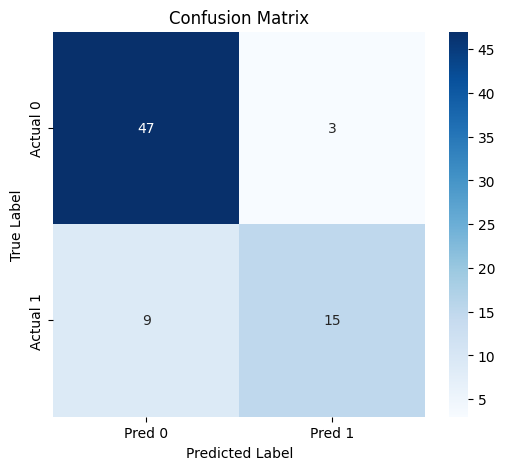

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(preds_df['Outcome'], preds_df['prediction'])

# Plot using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
